In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read CSV 
tracks_df = pd.read_csv("../data/top_tracks_2025-11-05.csv")
artists_df = pd.read_csv("../data/top_artists2025-11-05.csv")

# Shapes of Dataframe
print("Shape of Tracks DataFrame", tracks_df.shape)
print("Shape of Artists DataFrame", artists_df.shape)
tracks_df.head()

Shape of Tracks DataFrame (20, 7)
Shape of Artists DataFrame (20, 5)


,track_id,track_name,artist,album,duration_ms,popularity,spotify_url
0,7lq4b3sYM9cYSnCMxCafKe,TN,Morgan Wallen,I’m The Problem,185138,75,https://open.spotify.com/track/7lq4b3sYM9cYSnC...
1,0YsIYFRoxkmEvbKCwTp0Tg,20 Cigarettes,Morgan Wallen,I’m The Problem,160901,79,https://open.spotify.com/track/0YsIYFRoxkmEvbK...
2,1VmBvzkXWifvsz7lOsZyNI,Me To Me,Morgan Wallen,One Thing At A Time,138958,63,https://open.spotify.com/track/1VmBvzkXWifvsz7...
3,40SBS57su9xLiE1WqkXOVr,Afraid To Feel,LF SYSTEM,Afraid To Feel,177524,76,https://open.spotify.com/track/40SBS57su9xLiE1...
4,4gfrYDtaRmp6HPvN80V2ob,I Got Better,Morgan Wallen,I’m The Problem,204963,84,https://open.spotify.com/track/4gfrYDtaRmp6HPv...


In [14]:
# Data Cleaning
# Tracks 
print("Info:")
print(tracks_df.info()) 
print("Number of Missing Elements:")
print(tracks_df.isna().sum())

# Describe
tracks_df.describe()



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   track_id     20 non-null     object
 1   track_name   20 non-null     object
 2   artist       20 non-null     object
 3   album        20 non-null     object
 4   duration_ms  20 non-null     int64 
 5   popularity   20 non-null     int64 
 6   spotify_url  20 non-null     object
dtypes: int64(2), object(5)
memory usage: 1.2+ KB
None
Number of Missing Elements:
track_id       0
track_name     0
artist         0
album          0
duration_ms    0
popularity     0
spotify_url    0
dtype: int64


,duration_ms,popularity
count,20.000000,20.000000
mean,183341.950000,70.950000
std,26782.985232,9.832679
min,138958.000000,48.000000
25%,161284.250000,63.750000
50%,182921.500000,72.000000
75%,195932.750000,79.000000
max,239544.000000,85.000000


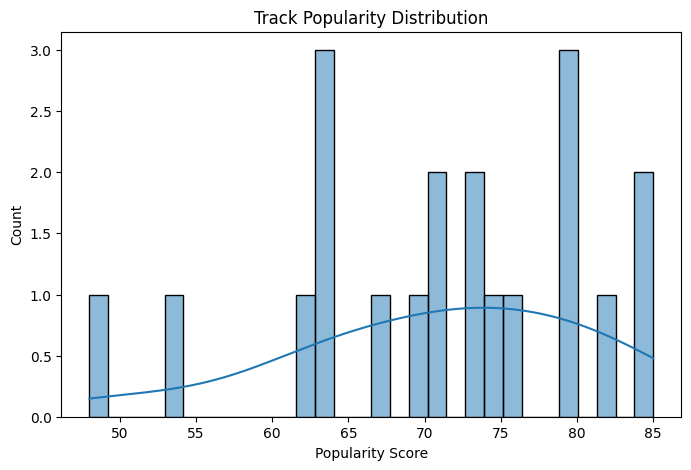

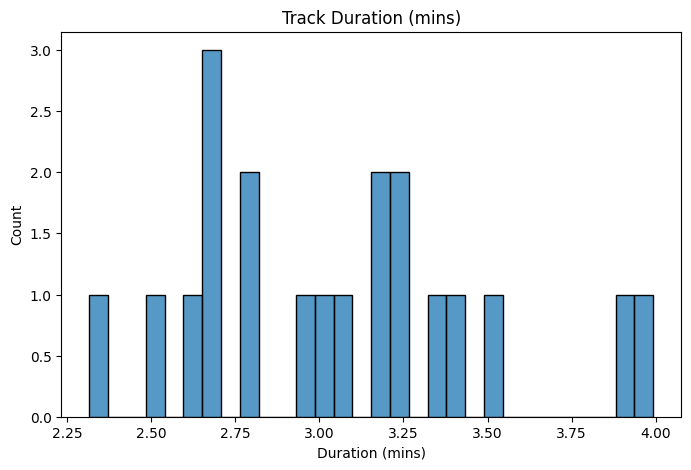

In [17]:
# Univariate Analysis
# Popularity Distribution
plt.figure(figsize=(8,5))
sns.histplot(tracks_df['popularity'], bins=30, kde=True)
plt.title("Track Popularity Distribution")
plt.xlabel("Popularity Score")
plt.show()

# Duration in minutes
tracks_df['duration_ms'] = tracks_df['duration_ms'] / 60000
plt.figure(figsize=(8,5))
sns.histplot(tracks_df['duration_ms'], bins=30)
plt.title("Track Duration (mins)")
plt.xlabel("Duration (mins)")
plt.show()


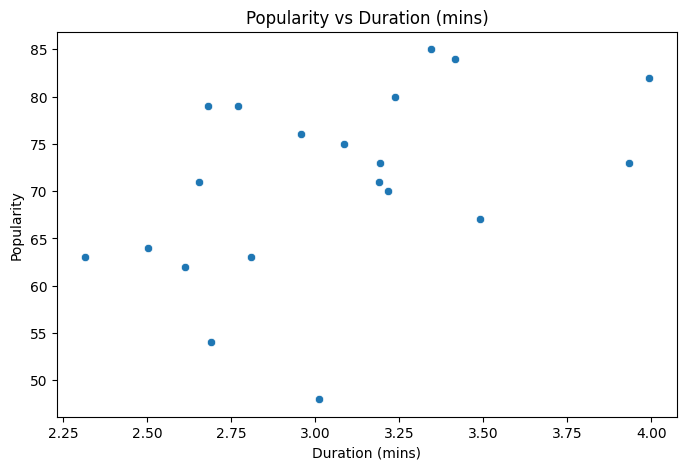

In [21]:
# Bivariate Analysis
# Popularity vs Duration (mins)
plt.figure(figsize=(8,5))
sns.scatterplot(x='duration_ms', y='popularity', data=tracks_df)
plt.title("Popularity vs Duration (mins)")
plt.xlabel("Duration (mins)")
plt.ylabel("Popularity")
plt.show()

In [36]:
# Very Low popularity outliers
outliers = tracks_df[tracks_df['popularity'] < 60]
print("Outlier tracks (popularity < 60):")
display(outliers[['track_name','artist','popularity']])

# Very long durations
long_tracks = tracks_df[tracks_df['duration_ms'] > tracks_df['duration_ms'].quantile(0.95)]
print("Long tracks:")
long_tracks[['track_name','artist','duration_ms']]


Outlier tracks (popularity < 60):


,track_name,artist,popularity
15,Sevan,PlaqueBoyMax,54
17,Stone Rolling,Rod Wave,48


Long tracks:


,track_name,artist,duration_ms
10,Where the Wild Things Are,Luke Combs,3.9924


In [ ]:
'''
Key Findings
- The distribution of track popularity is right-centered, with most of my top songs scoring between 65 and 80. This indicates a preference for tracks that are popular and widely streamed, rather than highly niche or extremely mainstream chart-topper
- Most of my top songs last from 2:30 to about 3:50 (mins).
- There does not seem to appear a strong relationship between popularity and duration in mins. Suggests track length is not that a meaningful factor in determining my listening preferences
- Two outliers of top tracks with a score of less than 60 (54 and 48)
- Longest Track is Where the Wild Things Are
'''

'\nKey Findings\n- The distribution of track popularity is right-centered, with most of my top songs scoring between 65 and 80. This indicates a preference for tracks that are popular and widely streamed, rather than highly niche or extremely mainstream chart-topper\n- Most of my top songs last from 2:30 to about 3:50 (mins).\n- There does not seem to appear a strong relationship between popularity and duration in mins. Suggests track length is not that a meaningful factor in determining my listening preferences\n'


Key Findings
- The distribution of track popularity is right-centered, with most of my top songs scoring between 65 and 80. This indicates a preference for tracks that are popular and widely streamed, rather than highly niche or extremely mainstream chart-topper
- Most of my top songs last from 2:30 to about 3:50 (mins).
- There does not seem to appear a strong relationship between popularity and duration in mins. Suggests track length is not that a meaningful factor in determining my listening preferences
- Two outliers of top tracks with a score of less than 60 (54 and 48)
- Longest Track is Where the Wild Things Are

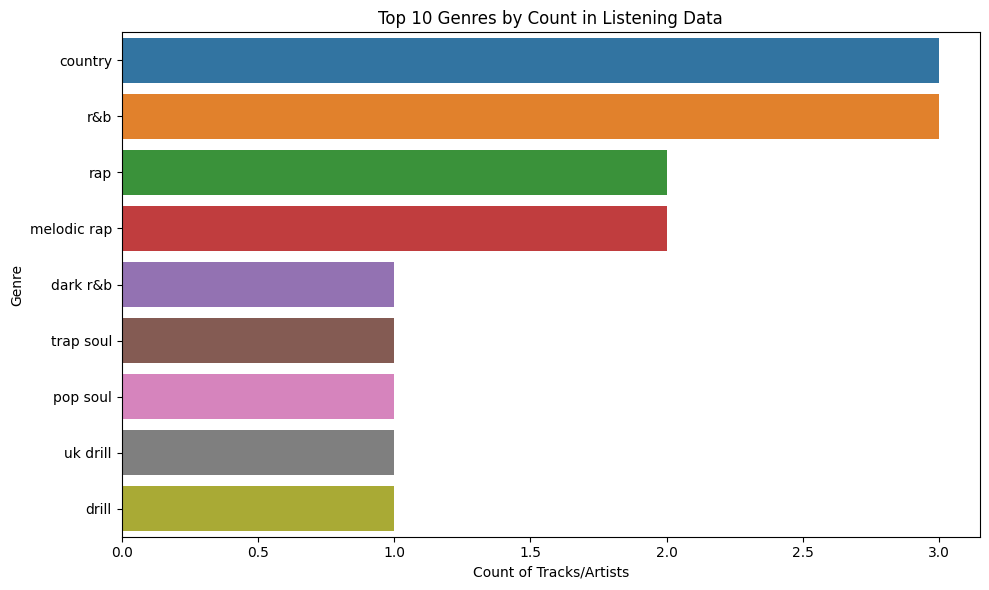

In [46]:
# Genre Frequency Bar Chart
genres_series = (
    artists_df['genres']
    .str.split(r',\s*')
    .explode()
    .str.strip()
    .value_counts()
)

# Top 10 Genres
top_genres = genres_series.head(10)
plt.figure(figsize=(10,6))
sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    hue=top_genres.index,
    legend=False
)
plt.title("Top 10 Genres by Count in Listening Data")
plt.xlabel("Count of Tracks/Artists")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

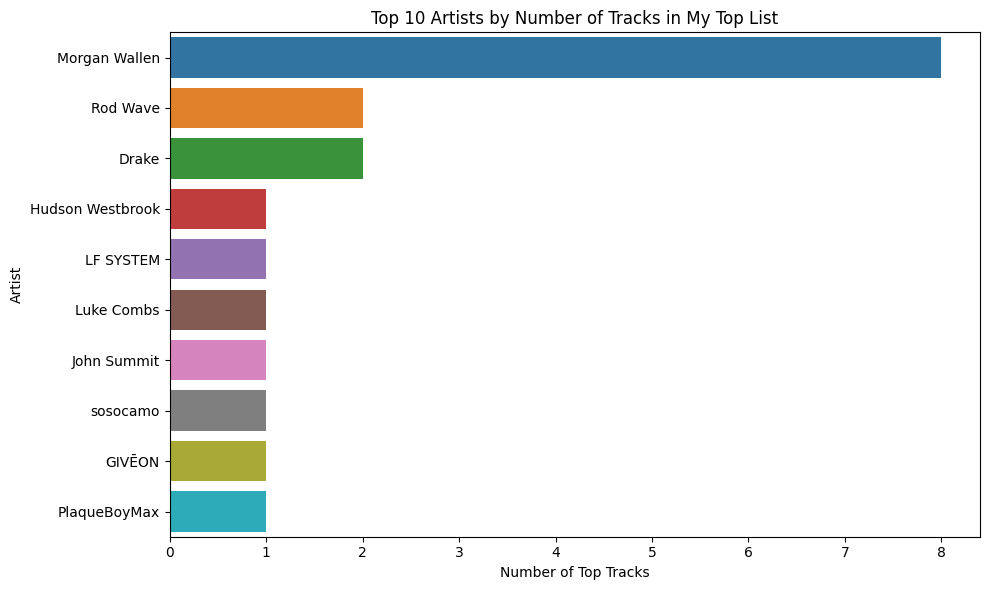

In [50]:
# Number of Tracks Per Artists
track_counts_by_artist = (
    tracks_df['artist']
    .value_counts()
)

top_artists_tracks = track_counts_by_artist.head(10)

plt.figure(figsize=(10,6))
sns.barplot(
    x=top_artists_tracks.values,
    y=top_artists_tracks.index,
    hue=top_artists_tracks.index,
    legend=False
)
plt.title("Top 10 Artists by Number of Tracks in My Top List")
plt.xlabel("Number of Top Tracks")
plt.ylabel("Artist")
plt.tight_layout()
plt.show()


Top Genres
- Country
- R&B
- RAP
Top Artists
- Morgan Wallen
- Rod Wave
- Drake